In [4]:
import numpy as np
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
from py_util_dx.py_utils import setProjectPath
import os, pickle
from visualizations import flatmap_real_vals, plot_flatmap_labels
from nitools.cifti import surf_from_cifti
from py_util_dx.data_utils import convert_prob_atlas_to_absolute_labels, get_roi_vtx_from_fs32k
from scipy.spatial.distance import pdist

In [5]:
projectPath, mainResultsPath = setProjectPath() 
dataset_name = 'MDTB' # or Demand

atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_74828/3564373629.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cosine_indiv_glasser[parI] = 1 - pdist(np.array([indiv_parcellation, group_parcellation]), metric='cosine')
/Users/jkderrick028/Documents/Projects/7TfMRI/PFC_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/PFC_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/PFC_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/PFC_parcellatio

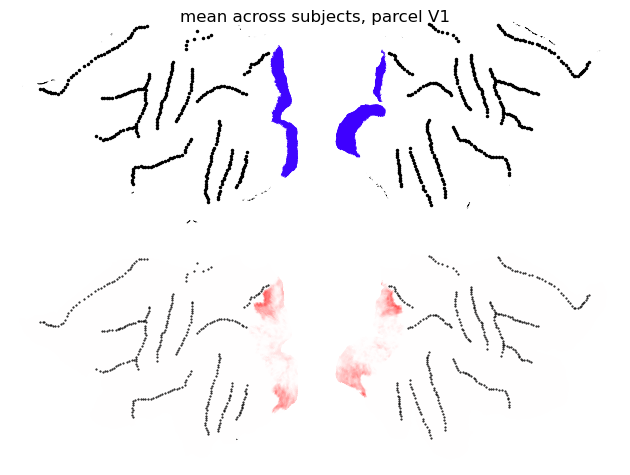

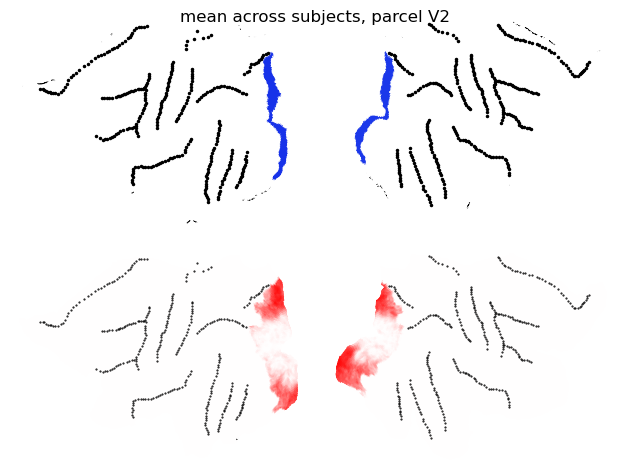

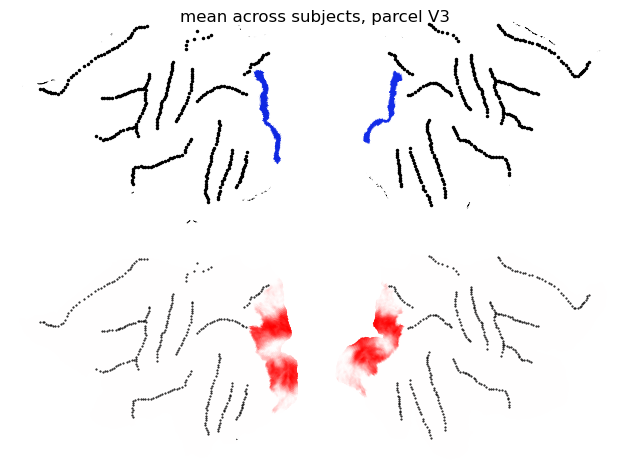

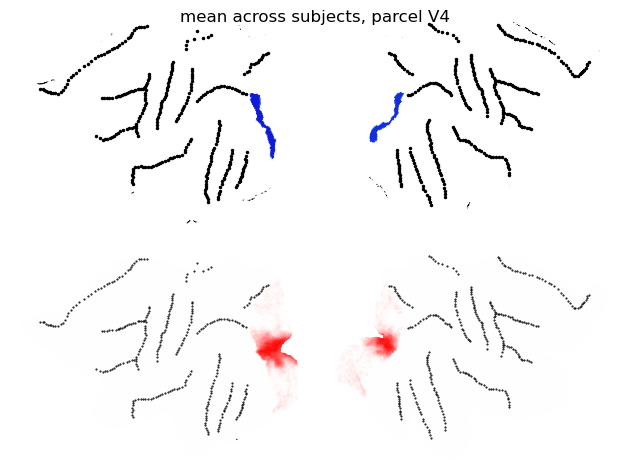

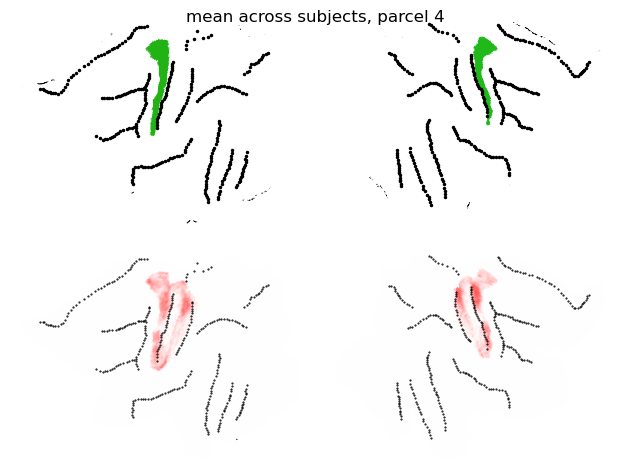

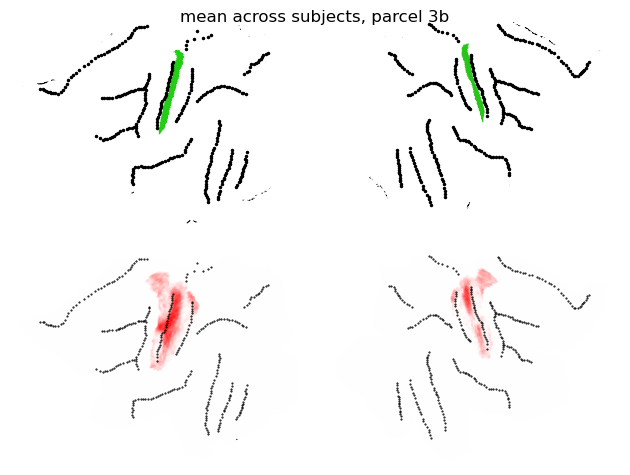

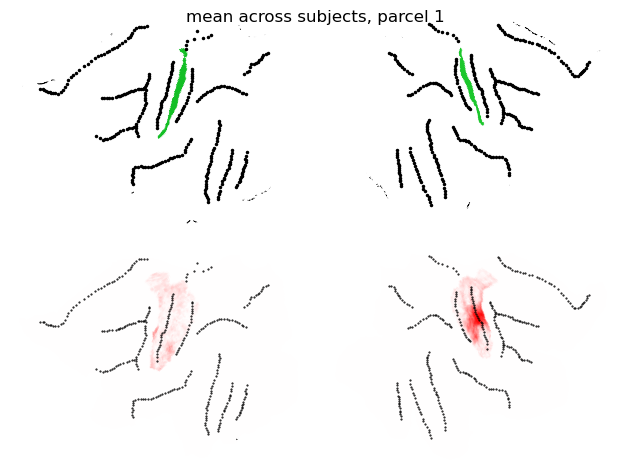

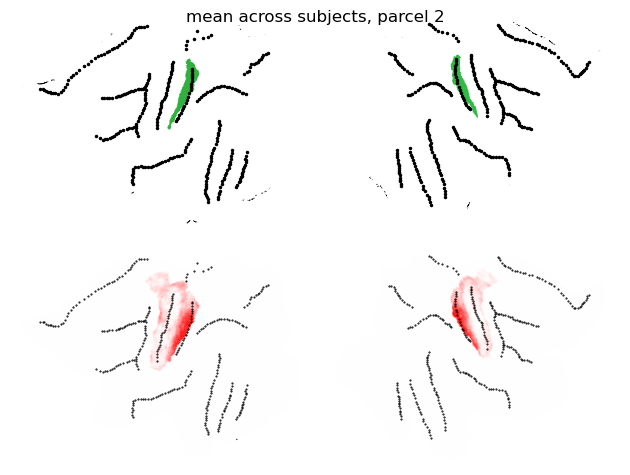

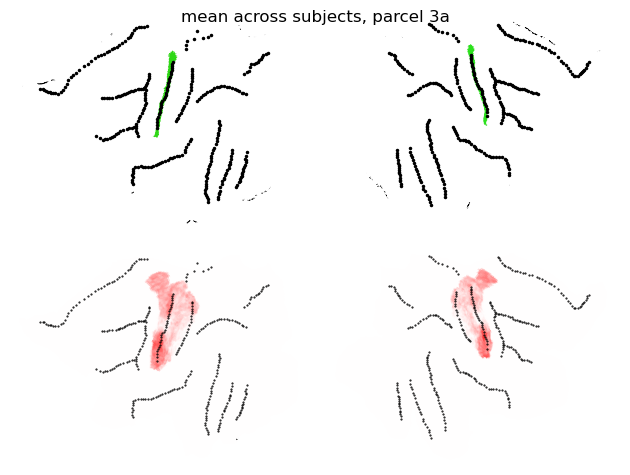

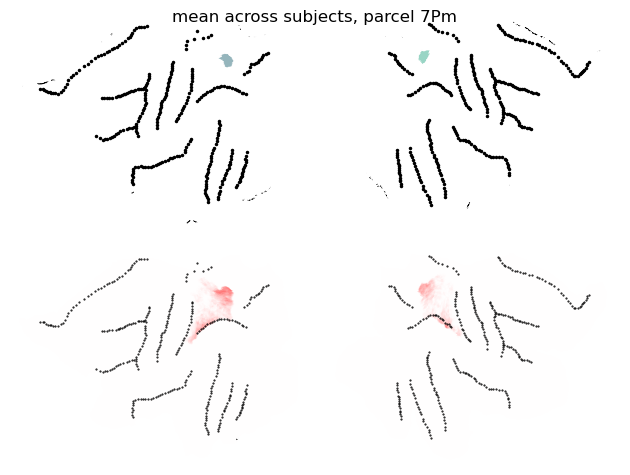

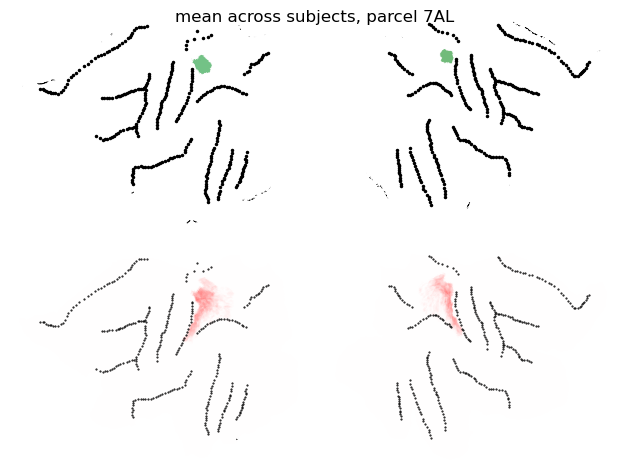

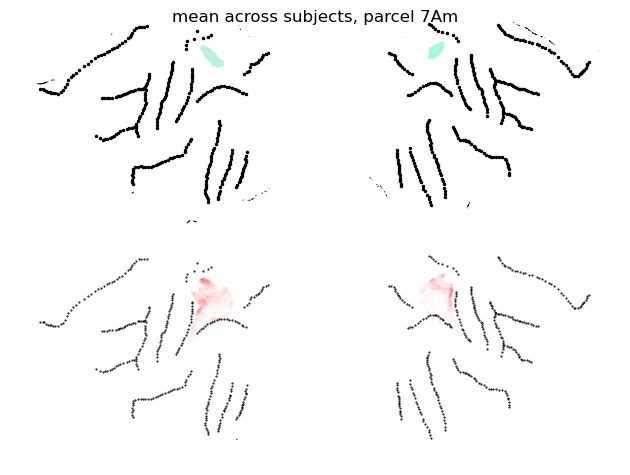

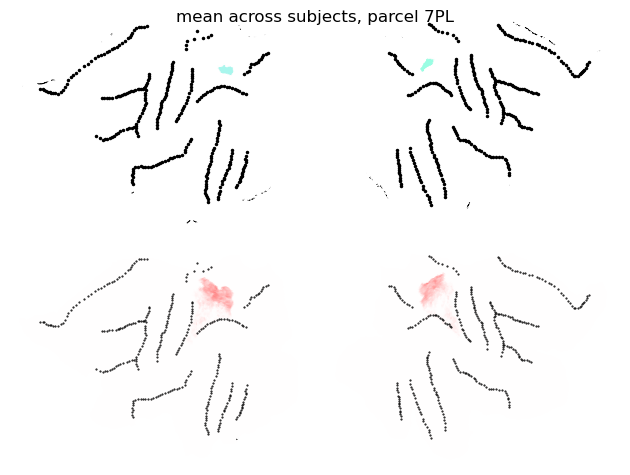

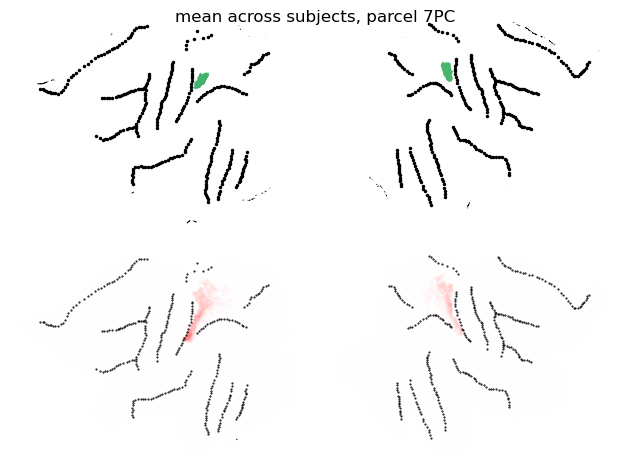

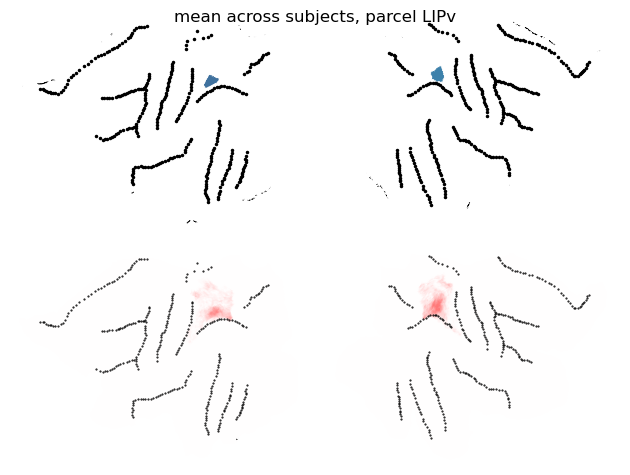

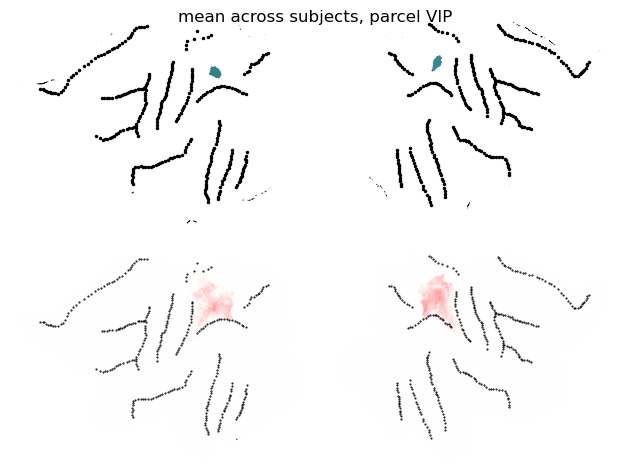

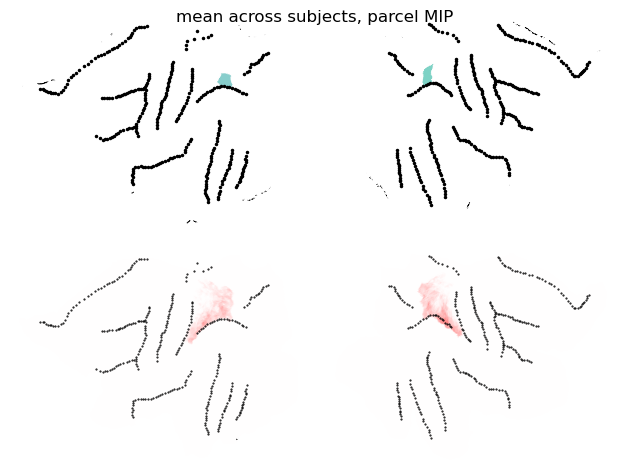

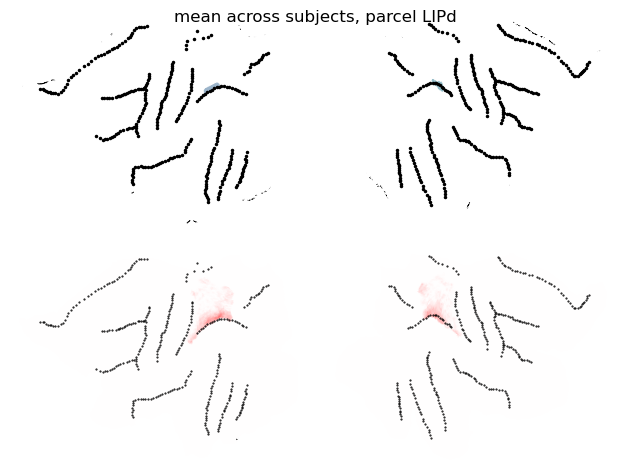

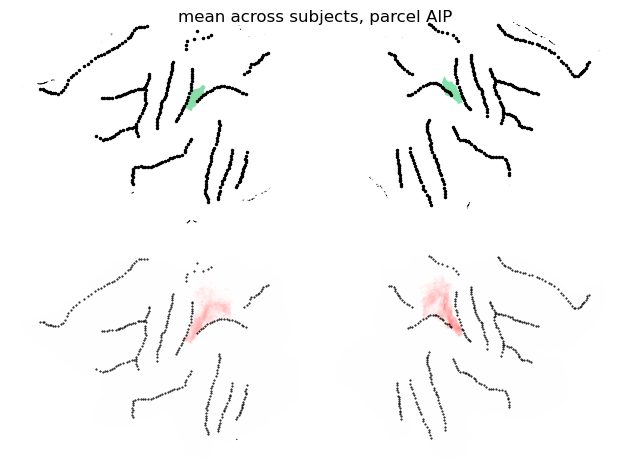

In [ ]:
strength = 7.0
ROIs = ['visual', 'somatosensory', 'parietal', 'PFC'] 
n_rois = len(ROIs) 

for roiI in np.arange(n_rois):
    included_vtx_inds_LR, included_vtx_inds_L, included_vtx_inds_R, excluded_vtx_inds_LR = get_roi_vtx_from_fs32k(ROIs[roiI])
    PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}_{strength}', f'output_{ROIs[roiI]}_masked.pkl')
    with open(PKL_individualized_parcellation, 'rb') as pf:
        output_indiv = pickle.load(pf)
        labels_in_glasser = output_indiv['labels_in_glasser']
        parcel_names_in_glasser = output_indiv['parcel_names_in_glasser']

        U_indiv = output_indiv['Uhat_data']
        U_indiv_label = convert_prob_atlas_to_absolute_labels(U_indiv, labels_in_glasser, excluded_vtx_inds_LR)
        U_group = output_indiv['U_roi']
        U_group_label = convert_prob_atlas_to_absolute_labels(U_group, labels_in_glasser, excluded_vtx_inds_LR).flatten()

        V = output_indiv['V'].T             # n_parcels x n_conditions

    n_subjects, n_parcels, P = U_indiv.shape

    ## for mean across subjects
    U_indiv_mean_across_subjects = np.mean(U_indiv, axis=0)

    # computing the correlation of the individualized atlas and the glasser group atlas
    cosine_indiv_glasser = np.zeros((n_parcels,))
    for parI in np.arange(n_parcels):
        indiv_parcellation = U_indiv_mean_across_subjects[parI, included_vtx_inds_LR]
        group_parcellation = U_group[parI, included_vtx_inds_LR]
        # corr_indiv_glasser[parI] = np.corrcoef(indiv_parcellation, group_parcellation)[0, 1]
        cosine_indiv_glasser[parI] = 1 - pdist(np.array([indiv_parcellation, group_parcellation]), metric='cosine')[0]

    for parI in np.arange(n_parcels):
        plt.figure()
        group_label = 181 * np.ones(U_group_label.shape)
        group_label = group_label.astype(int)
        group_label[U_group_label == labels_in_glasser[parI]] = labels_in_glasser[parI]
        [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(group_label.reshape(1, -1)))

        plt.subplot(2, 2, 1)
        plot_flatmap_labels(label_L, 'L')

        plt.subplot(2, 2, 2)
        plot_flatmap_labels(label_R, 'R')

        surf_data = U_indiv_mean_across_subjects[parI]
        plt.subplot(2, 2, 3)
        flatmap_real_vals(surf_data, 'L')

        plt.subplot(2, 2, 4)
        flatmap_real_vals(surf_data, 'R')

        plt.tight_layout()
        plt.suptitle(f'{ROIs[roiI]}, {parcel_names_in_glasser[parI]}')

    print(f'cosine similarity {ROIs[roiI]}: {cosine_indiv_glasser}') 

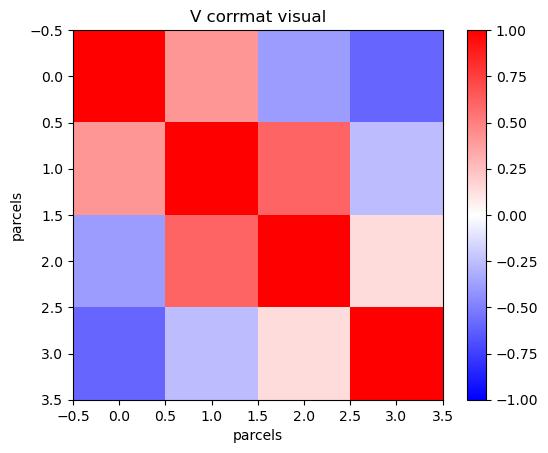

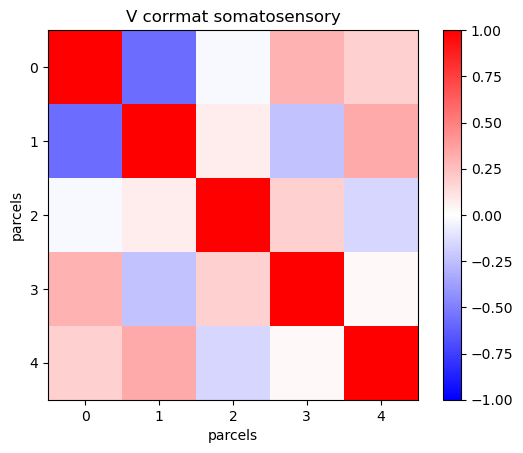

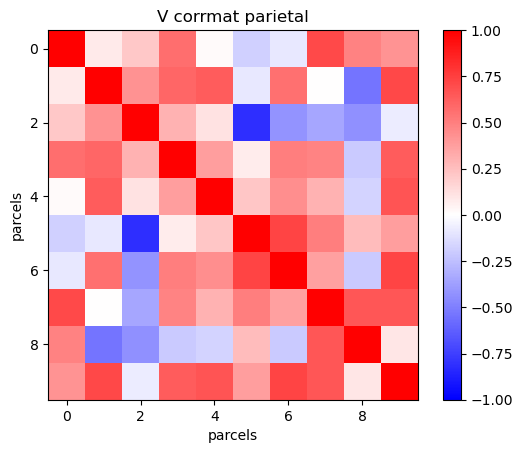

In [7]:
for roiI in np.arange(n_rois):
    included_vtx_inds_LR, included_vtx_inds_L, included_vtx_inds_R, excluded_vtx_inds_LR = get_roi_vtx_from_fs32k(ROIs[roiI])
    PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}_{strength}', f'output_{ROIs[roiI]}_masked.pkl')
    with open(PKL_individualized_parcellation, 'rb') as pf:
        output_indiv = pickle.load(pf)        
        V = output_indiv['V'].T             # n_parcels x n_conditions

    V_simmats = np.corrcoef(V)
    
    fig, ax = plt.subplots(1, 1)
    im = ax.imshow(V_simmats, cmap='bwr', vmin=-1, vmax=1)
    ax.set_aspect('equal')
    plt.colorbar(im)
    ax.set_title(f'V corrmat {ROIs[roiI]}')
    ax.set_xlabel('parcels')
    ax.set_ylabel('parcels')